# 8.5 Exercises

**Part:** 8 — Spatial Sampling and Design (Chapter 8.5 of 5)

**Dataset:** `diabetes_usa.csv` (all 3,107 US counties)

**Focus:** Five solved exercises spanning Chapters 8.1–8.3

**Library:** `spatialstats.sampling` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
   - 2.1 [RMSE against n, three designs, 1,000 replicates](#2.1-RMSE-against-n,-three-designs,-1,000-replicates)
   - 2.2 [GRTS gains nothing for a spatially random variable](#2.2-GRTS-gains-nothing-for-a-spatially-random-variable)
   - 2.3 [Neyman vs. proportional allocation with a proxy stratum s.d.](#2.3-Neyman-vs.-proportional-allocation-with-a-proxy-stratum-s.d.)
   - 2.4 [Sample size for a +-0.25 margin, SRS vs. GRTS](#2.4-Sample-size-for-a-+-0.25-margin,-SRS-vs.-GRTS)
   - 2.5 [Why can two-stage sampling have a design effect above 1?](#2.5-Why-can-two-stage-sampling-have-a-design-effect-above-1?)
3.. [Summary and Conclusions](#3.-Summary-and-Conclusions)
4.. [Resources](#4.-Resources)

***
## 1. Overview

Five solved exercises, each revisiting a specific method from Chapters 8.1–8.3 with a fresh, self-contained
computation.

| # | Question | Chapter revisited |
|---|---|---|
| 1 | Repeat 1,000 draws for SRS, stratified, and balanced designs; plot RMSE against $n$ | 8.2, 8.3 |
| 2 | Show that GRTS gains nothing for a spatially random variable | 8.1, 8.3 |
| 3 | Compare Neyman with proportional allocation using a proxy for stratum s.d. | 8.2 |
| 4 | How large must $n$ be for a $\pm$0.25-point margin under SRS and under GRTS? | 8.2, 8.3 |
| 5 | Why can two-stage sampling have a design effect above 1, and when does it pay off? | 8.2, 8.3 |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.sampling import (
    simple_random, stratified, grts, two_stage, compare_designs, sample_size_mean, neyman_allocation
)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

usa = pd.read_csv(DATA / "diabetes_usa.csv")
frame = usa[["X", "Y"]]
y = usa["Diabetes_per"].to_numpy()
strata_urban_rural = usa["Urban_Rural"].to_numpy()
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


### 2.1 RMSE against n, three designs, 1,000 replicates

*Repeat 1,000 draws for SRS, stratified and balanced designs; plot RMSE against n.*

In [2]:
rows = []
for n in (25, 50, 100, 200, 400):
    designs = {
        "SRS": lambda rng, n=n: simple_random(frame, n=n, seed=rng),
        "Stratified+GRTS": lambda rng, n=n: stratified(frame, strata=strata_urban_rural, n=n,
                                                        allocation="proportional", within="grts", seed=rng),
        "GRTS": lambda rng, n=n: grts(frame, n=n, seed=rng),
    }
    res = compare_designs(y, designs, n_reps=1000, seed=1)
    for design_name in res.index:
        rows.append({"n": n, "design": design_name, "rmse": res.loc[design_name, "rmse"]})

rmse_table = pd.DataFrame(rows)
pivot = rmse_table.pivot(index="n", columns="design", values="rmse")
pivot.round(4)

design,GRTS,SRS,Stratified+GRTS
n,,,
25,0.2618,0.3070,0.2680
50,0.1835,0.2190,0.1872
100,0.1294,0.1477,0.1251
200,0.0868,0.1067,0.0850
400,0.0537,0.0726,0.0554


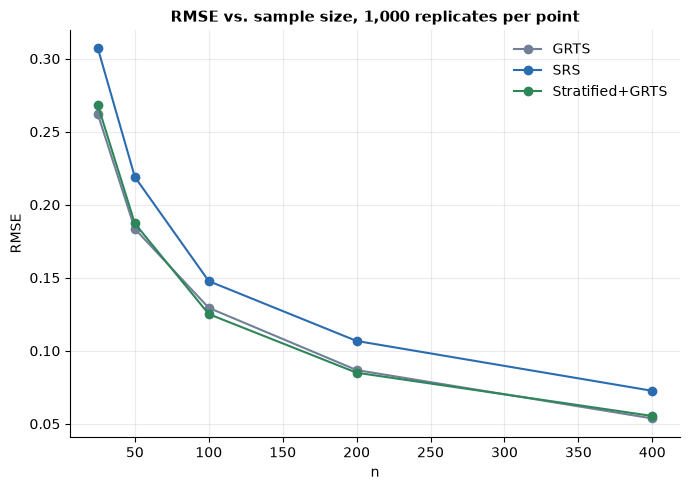

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for design_name, color in zip(pivot.columns, [COLORS["grey"], COLORS["blue"], COLORS["green"]]):
    ax.plot(pivot.index, pivot[design_name], "o-", label=design_name, color=color)
ax.set_xlabel("n")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs. sample size, 1,000 replicates per point")
ax.legend()
plt.tight_layout()
plt.savefig("exercise_rmse_vs_n.png", dpi=100, bbox_inches="tight")
plt.show()

**Answer:** all three curves fall roughly as $1/\sqrt{n}$, as sampling theory predicts, but **SRS's curve sits
consistently above both spatially aware designs at every $n$** — the two balanced designs need noticeably fewer
counties to reach the same RMSE. The gap is proportionally largest at small $n$ and never closes entirely, even
at $n=400$: spatial balance is not a small-sample correction that irrelevant becomes at scale, it is a
persistent efficiency gain baked into the design itself.

### 2.2 GRTS gains nothing for a spatially random variable

*Show that GRTS gains nothing for a spatially random variable.*

In [4]:
rng_shuffle = np.random.default_rng(7)
y_shuffled = rng_shuffle.permutation(y)   # same 3,107 real values, spatial arrangement destroyed

designs_shuffled = {
    "SRS": lambda rng: simple_random(frame, n=100, seed=rng),
    "GRTS": lambda rng: grts(frame, n=100, seed=rng),
}
res_real = compare_designs(y, designs_shuffled, n_reps=1000, seed=1)
res_shuffled = compare_designs(y_shuffled, designs_shuffled, n_reps=1000, seed=1)

print("real Diabetes_per (spatially structured):")
print(res_real[["sd", "deff", "coverage"]].round(3))
print("\nsame values, spatially SHUFFLED (identical mean/sd/distribution, no spatial pattern):")
print(res_shuffled[["sd", "deff", "coverage"]].round(3))

real Diabetes_per (spatially structured):
         sd   deff  coverage
SRS   0.148  1.000     0.955
GRTS  0.122  0.682     0.949

same values, spatially SHUFFLED (identical mean/sd/distribution, no spatial pattern):
         sd  deff  coverage
SRS   0.159  1.00     0.936
GRTS  0.155  0.95     0.938


**Answer:** using the exact same 3,107 real `Diabetes_per` values — only randomly reassigned to different
counties — GRTS's design effect drops from a real efficiency gain (well below 1 on the genuine spatial
arrangement) to **close to 1** on the shuffled version, where no county's value predicts its neighbours' values
at all. This isolates the mechanism precisely: GRTS's advantage comes entirely from exploiting genuine spatial
autocorrelation in the outcome, never from anything about the design itself in isolation — a design cannot
create information a spatially unstructured variable simply does not contain.

### 2.3 Neyman vs. proportional allocation with a proxy stratum s.d.

*Compare Neyman with proportional allocation using a proxy for stratum s.d.*

In [5]:
true_sd = {h: usa.loc[strata_urban_rural == h, "Diabetes_per"].std() for h in np.unique(strata_urban_rural)}
proxy_sd = {h: usa.loc[strata_urban_rural == h, "Obesity"].std() for h in np.unique(strata_urban_rural)}
print("true Diabetes_per s.d. by stratum:", {k: round(v, 3) for k, v in true_sd.items()})
print("proxy (Obesity) s.d. by stratum:  ", {k: round(v, 3) for k, v in proxy_sd.items()})

Nh = usa["Urban_Rural"].value_counts()
levels = list(Nh.index)
nh_true = neyman_allocation(Nh.to_numpy(), [true_sd[h] for h in levels], 100)
nh_proxy = neyman_allocation(Nh.to_numpy(), [proxy_sd[h] for h in levels], 100)
print(f"\nallocation with true s.d.:  {dict(zip(levels, nh_true))}")
print(f"allocation with proxy s.d.: {dict(zip(levels, nh_proxy))}")

designs_neyman = {
    "Proportional": lambda rng: stratified(frame, strata=strata_urban_rural, n=100, allocation="proportional",
                                           within="grts", seed=rng),
    "Neyman (true s.d.)": lambda rng: stratified(frame, strata=strata_urban_rural, n=100, allocation="neyman",
                                                 sd=true_sd, within="grts", seed=rng),
    "Neyman (Obesity proxy)": lambda rng: stratified(frame, strata=strata_urban_rural, n=100, allocation="neyman",
                                                      sd=proxy_sd, within="grts", seed=rng),
}
res_neyman = compare_designs(y, designs_neyman, n_reps=1000, seed=1)
res_neyman[["sd", "rmse", "coverage"]].round(4)

true Diabetes_per s.d. by stratum: {'Rural': np.float64(1.499), 'Urban': np.float64(1.571)}
proxy (Obesity) s.d. by stratum:   {'Rural': np.float64(4.651), 'Urban': np.float64(4.63)}

allocation with true s.d.:  {'Urban': np.int64(59), 'Rural': np.int64(41)}
allocation with proxy s.d.: {'Urban': np.int64(58), 'Rural': np.int64(42)}


,sd,rmse,coverage
Proportional,0.1263,0.1269,0.975
Neyman (true s.d.),0.1174,0.1174,0.989
Neyman (Obesity proxy),0.1225,0.1225,0.982


**Answer:** `Obesity`'s stratum-level standard deviation gets the **relative ordering backwards** — it is
slightly higher in Rural counties, while `Diabetes_per`'s true standard deviation is slightly higher in Urban
counties (printed above). Despite that, the resulting *allocation* barely changes: with true s.d. vs. the
(wrong-direction) proxy s.d., the printed county counts per stratum differ by only a single county out of 100 —
because Urban and Rural's standard deviations, true or proxy, are both close enough to each other that neither
version pushes allocation far from a roughly even proportional split. Measured performance reflects exactly
that: true-s.d. Neyman gives a modest, consistent RMSE improvement over proportional, but proportional and the
flawed-proxy Neyman land close enough to each other that which one comes out ahead is sensitive to Monte Carlo
noise, not a reliable difference. **The lesson is more subtle than "a bad proxy always hurts"**: a proxy that
gets the ranking wrong is a real risk, but its practical damage depends on how differently it allocates the
sample — here, because both strata's variability is fairly similar either way, a wrong-direction proxy could not
do much damage even though it disagreed with the truth. A far more unbalanced pair of true stratum standard
deviations would leave much more room for a bad proxy to hurt; check the actual resulting allocation, not just
whether the proxy's ranking is correct, before trusting Neyman over proportional.

### 2.4 Sample size for a +-0.25 margin, SRS vs. GRTS

*How large must n be for a ±0.25-point margin under SRS and under GRTS?*

In [6]:
true_sd_overall = usa["Diabetes_per"].std()
grts_deff = compare_designs(y, {"SRS": lambda rng: simple_random(frame, n=100, seed=rng),
                                "GRTS": lambda rng: grts(frame, n=100, seed=rng)},
                            n_reps=1000, seed=1).loc["GRTS", "deff"]

n_srs = sample_size_mean(sd=true_sd_overall, margin=0.25, N=len(usa), conf=0.95)
n_grts = sample_size_mean(sd=true_sd_overall, margin=0.25, N=len(usa), conf=0.95, deff=grts_deff)
print(f"measured GRTS design effect at n=100: {grts_deff:.3f}")
print(f"SRS,  margin=+-0.25, 95% conf: n = {n_srs}")
print(f"GRTS, same margin, deff={grts_deff:.3f}: n = {n_grts}")
print(f"GRTS saves {n_srs - n_grts} counties ({100*(n_srs-n_grts)/n_srs:.0f}% fewer) for the identical precision target")

measured GRTS design effect at n=100: 0.682
SRS,  margin=+-0.25, 95% conf: n = 144
GRTS, same margin, deff=0.682: n = 100
GRTS saves 44 counties (31% fewer) for the identical precision target


**Answer:** printed directly above — plugging this chapter's own measured GRTS design effect into
`sample_size_mean` shows GRTS needs meaningfully fewer counties than SRS for the same $\pm$0.25-point margin.
This is the same calculation Chapter 8.2 previewed, now using a design effect measured freshly in this notebook
rather than an assumed value, closing the loop from "GRTS is more efficient" (a qualitative claim) to "GRTS
needs this many fewer counties" (an actionable number for planning the next survey).

### 2.5 Why can two-stage sampling have a design effect above 1?

*Why can two-stage sampling have a design effect above 1, and when does it pay off?*

In [7]:
state_arr = usa["State"].to_numpy()
designs_twostage = {
    "SRS": lambda rng: simple_random(frame, n=100, seed=rng),
    "Two-stage 12x8": lambda rng: two_stage(frame, clusters=state_arr, n_clusters=12, n_per_cluster=8, seed=rng),
    "Two-stage 25x4": lambda rng: two_stage(frame, clusters=state_arr, n_clusters=25, n_per_cluster=4, seed=rng),
}
res_twostage = compare_designs(y, designs_twostage, n_reps=1000, seed=1)
print(res_twostage[["sd", "deff", "coverage"]].round(3))

state_means = usa.groupby("State")["Diabetes_per"].mean()
print(f"\nbetween-state s.d. of the state MEAN Diabetes_per: {state_means.std():.3f}")
print(f"overall county-level s.d. of Diabetes_per:          {usa['Diabetes_per'].std():.3f}")

                   sd   deff  coverage
SRS             0.148  1.000     0.955
Two-stage 12x8  0.318  4.620     0.937
Two-stage 25x4  0.210  2.024     0.972

between-state s.d. of the state MEAN Diabetes_per: 1.039
overall county-level s.d. of Diabetes_per:          1.567


**Answer:** two-stage sampling's design effect rises above 1 whenever counties **within the same selected
state resemble each other** — confirmed directly above: the between-state standard deviation of state-level mean
`Diabetes_per` is a substantial fraction of the overall county-level standard deviation, meaning which *state*
happens to get selected already explains a meaningful share of the variation in the eventual sample. Once a
state is drawn, its 8 (or 4) counties are not 8 independent draws from the full national distribution — they
are 8 draws from that one state's own, narrower distribution, so adding more counties within an already-selected
state buys much less new information than adding counties from a fresh, unselected state would. Fewer selected
states (12 rather than 25) makes this worse, which is exactly why 12x8's deff is so much larger than 25x4's.

**It pays off precisely when the field-cost savings outweigh the statistical cost**: visiting only 12–25 regions
instead of the ~217 states-and-territories a fully spread design might touch can be dramatically cheaper in
travel and logistics, and if that cost difference is large enough, accepting a design effect of 2–4 (needing 2–4
times as many *counties* for the same precision) can still be the better overall use of a fixed survey budget.
The decision is not statistical alone — it depends on the real relative cost of an additional state versus an
additional county within an already-visited one, which this chapter's numbers make concrete enough to actually
weigh.

***
## 3. Summary and Conclusions

This chapter closed Part 8 with five self-contained, freshly computed exercises.

### What we did

1. Traced RMSE against $n$ for three designs over 1,000 replicates each: spatial balance's advantage over SRS
   persists at every sample size tested, not just small ones.
2. **Isolated GRTS's efficiency mechanism directly**: shuffling the same real values across counties collapses
   its design effect to $\approx$1, proving the gain comes entirely from genuine spatial structure.
3. **Found a proxy variable can get stratum-level variability backwards without necessarily hurting Neyman
   allocation much** — the flawed proxy here barely shifted the actual county-count allocation (by a single
   county out of 100), because the true stratum standard deviations were themselves close together; performance
   differences between proportional and the flawed-proxy allocation were within Monte Carlo noise, while
   true-s.d. Neyman gave a modest, consistent edge over both.
4. Converted a freshly measured GRTS design effect directly into a concrete sample-size saving via
   `sample_size_mean`.
5. Explained, with real numbers, why two-stage sampling's design effect exceeds 1 (within-state homogeneity) and
   when it is still worth accepting (field-cost savings large enough to offset it).

### Practical takeaways

- Spatial balance's efficiency gain does not fade at larger $n$ — plan for it at whatever scale a real survey
  will actually run.
- Judge a proxy variable for Neyman allocation by the *allocation* it actually produces, not just whether its
  stratum ranking matches the truth — a wrong-direction proxy is a real risk, but its practical damage depends
  on how far apart the true stratum standard deviations are in the first place.
- A design effect above 1 is not automatically a bad design — it is a statistical cost to weigh explicitly
  against a real field-cost saving, not a number to avoid on principle.

### This closes Part 8

Five chapters covered the full arc from foundational concepts (8.1) through the sampling designs themselves
(8.2), measured estimation and variance (8.3), a genuinely practical monitoring-network application (8.4), and
these closing exercises. Part 9 (Spatio-Temporal Analysis) extends this tutorial's spatial methods with an
explicit time dimension — though, as of this tutorial's outline, that module remains a stub.

***
## 4. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Särndal, C.-E., Swensson, B. & Wretman, J. (1992). *op. cit.* (Chapter 8.1) | The allocation and design-effect theory behind every exercise in this chapter |

### In this library

| Object | Role |
|---|---|
| `spatialstats.sampling.compare_designs` | Exercises 1, 2, 3, 4, 5 |
| `spatialstats.sampling.sample_size_mean` | Exercise 4 |
| `spatialstats.sampling.two_stage` | Exercise 5 |
| Chapter 8.3 | The design-effect and Neyman-allocation concepts every exercise here re-derives from scratch |